Your README must contain:
• Original research question from Phase 1
• Your target variable and all features used across Phase 3 and Phase 4
• Final dataset shape used for modeling (rows x columns)
• One sentence describing what changed between Phase 3 and Phase 4 and why

You must write 3 to 5 sentences answering the following in your notebook:
• What was the evaluation setup in Phase 3, and why is it problematic?
• What does a train/test split fix, in your own words?
• Do you expect your Phase 3 RMSE to go up or down when evaluated on held-out data,
and why?


Part 1:

The evaluation setup for phase 3 was training on a full dataset whcih is problematic because the model memorizes the dataset rather than learn and predicting. Test and training datasets allow the model to predict behavior given some information and then applies the patterns it recognized to a dataset it does not know. We can expect our phase 3 RMSE to increase because rather than memorizing patterns and noise in the data it was trained on, it is tested with data it has not seen before which will create more mistakes.

In [42]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.graph_objects as go

df = pd.read_csv('phase3.csv')

In [43]:
df

,Date,Close_Splits,Volume_Splits,Open_Splits,High_Splits,Low_Splits,Open_NoSplits,High_NoSplits,Low_NoSplits,Close_NoSplits,...,Price_Range,Price_Change,Profit,pred_constant,error,squared_error,pred_linear,error_linear,squared_error_linear,Prev_Close
0,2020-02-27,$273.52,80151380,$281.1,$286,$272.96,67.984578,69.169651,66.015900,66.151337,...,3.153751,-1.833242,False,26.17548,39.975856,1598.069090,67.353379,-1.202042,1.444906,66.112656
1,2020-02-26,$292.65,49678430,$286.53,$297.88,$286.5,69.297844,72.042865,69.290589,70.777977,...,2.752277,1.480133,True,26.17548,44.602497,1989.382708,68.220993,2.556984,6.538168,66.151337
2,2020-02-25,$288.08,57668360,$300.95,$302.53,$286.13,72.785347,73.167470,69.201100,69.672707,...,3.966371,-3.112641,False,26.17548,43.497226,1892.008693,72.109833,-2.437127,5.939587,70.777977
3,2020-02-24,$298.18,55548830,$297.26,$304.18,$289.23,71.892933,73.566545,69.950862,72.115433,...,3.615683,0.222500,True,26.17548,45.939952,2110.479227,71.142269,0.973164,0.947048,69.672707
4,2020-02-21,$313.05,32426420,$318.62,$320.45,$310.5,77.058879,77.501472,75.095042,75.711761,...,2.406430,-1.347117,False,26.17548,49.536281,2453.843149,75.357597,0.354165,0.125433,72.115433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2512,2010-03-05,$31.2786,224647427,$30.7057,$31.3857,$30.6614,6.446276,6.589033,6.436978,6.566540,...,0.152055,0.120264,True,26.17548,-19.608941,384.510550,6.474153,0.092387,0.008535,6.570438
2513,2010-03-04,$30.1014,89591907,$29.8971,$30.1314,$29.8043,6.276525,6.325710,6.257030,6.319412,...,0.068680,0.042887,True,26.17548,-19.856069,394.263459,6.362392,-0.042981,0.001847,6.566540
2514,2010-03-03,$29.9043,92846488,$29.8486,$29.9814,$29.7057,6.266330,6.294222,6.236339,6.278026,...,0.057882,0.011696,True,26.17548,-19.897454,395.908685,6.269189,0.008837,0.000078,6.319412
2515,2010-03-02,$29.8357,141486282,$29.99,$30.1186,$29.6771,6.296020,6.323012,6.230339,6.263630,...,0.092672,-0.032390,False,26.17548,-19.911850,396.481787,6.273999,-0.010369,0.000108,6.278026


In [44]:
#Part 2
from sklearn.model_selection import train_test_split
X = df[['Open_NoSplits']] # your Phase 3 feature
y = df['Close_NoSplits']
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)

In [45]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2013, 1)
(504, 1)
(2013,)
(504,)


In [46]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
rmse_test = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
print('Test RMSE:', rmse_test)


Test RMSE: 0.3122395139557987


Surprisingly, our model performed better on held-out data, the difference was small with about a 0.02 difference in RMSE. Because our RMSE was decreased we can say that our model our model was generalized pretty well.

In [47]:
#part 3a
df1 = df.copy()
df1['log_Open'] = np.log1p(df['Open_NoSplits'])

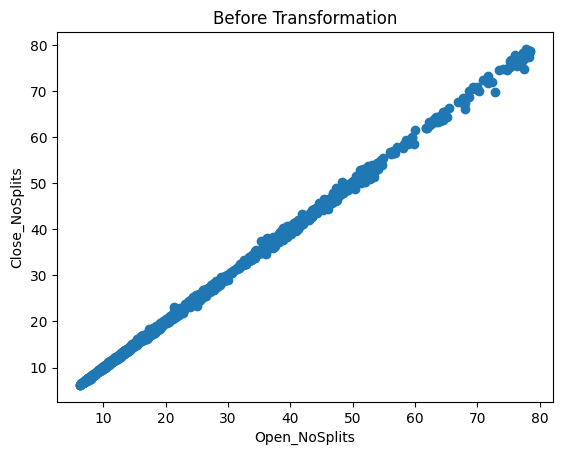

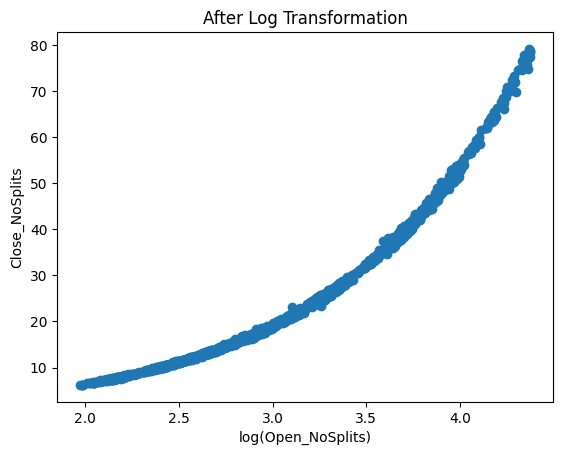

In [48]:
# Before
plt.scatter(df['Open_NoSplits'], df['Close_NoSplits'])
plt.xlabel('Open_NoSplits')
plt.ylabel('Close_NoSplits')
plt.title('Before Transformation')
plt.show()

# After
plt.scatter(df1['log_Open'], df1['Close_NoSplits'])
plt.xlabel('log(Open_NoSplits)')
plt.ylabel('Close_NoSplits')
plt.title('After Log Transformation')
plt.show()

The log transformation was not helpful and was counterproductive for showing the relationship between open and close values with no splits because the relatiosnhip started with a strong linear relationship and was transformed into a curved and nonlinear relationship. This shows that the transformation was not useful because a curved relationship is less suitable for a linear regression model.

In [49]:
#3b
df['interaction'] = df['Open_NoSplits'] * df['Prev_Close']

Justify your interaction term in 1 to 2 sentences. Why do you believe these two variables might
have a combined effect on your target? What would it mean if the interaction term improves
your model?
From our visualizations earlier we can conclude that Open_NoSplits has a strong linear relationship already. Additionaly, Prev_Close was shown to lower our RMSE score in phase 3 which combined into an interaction feature may make our prediction more accurate, if the model is improved that shows the effect of the opening price is dependent on the closing price.

In [50]:
df1['feature_binned'] = pd.cut(df1['Open_NoSplits'], bins=4, labels=False)

If you use binning, you must justify why you believe the relationship between your feature and
target is not linear. Cite your Phase 3 residual plot as evidence if applicable.

I decided to not utilize binning with Open_NoSplits because the residual plot already showed no clear pattern nor curvature with residuals scattered around 0. This indicates the relationship was already linear and a binned feature would not improve features.  

In [ ]:
#note to nate: use df and not df1, df1 was used to test log transformation and binning, but I decided it wouldn't improve the model, please use df
#also i wasn't really sure if I was only supposed to use Open_NoSplits on every part of 3, but I did anyways, if you think otherwise you are free to let me know and I can change it